In [4]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score 


In [5]:
df=pd.read_csv("temperatures.csv")

In [6]:
df

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,2013,24.56,26.59,30.62,32.66,34.46,32.44,31.07,30.76,31.04,30.27,27.83,25.37,29.81,25.58,32.58,31.33,27.83
113,2014,23.83,25.97,28.95,32.74,33.77,34.15,31.85,31.32,30.68,30.29,28.05,25.08,29.72,24.90,31.82,32.00,27.81
114,2015,24.58,26.89,29.07,31.87,34.09,32.48,31.88,31.52,31.55,31.04,28.10,25.67,29.90,25.74,31.68,31.87,28.27
115,2016,26.94,29.72,32.62,35.38,35.72,34.03,31.64,31.79,31.66,31.98,30.11,28.01,31.63,28.33,34.57,32.28,30.03


In [17]:
df.corr()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,Output_Feature
YEAR,1.000000,0.575499,0.647066,0.553886,0.540662,0.407648,0.371840,0.478512,0.654138,0.664008,0.589073,0.697887,0.732222,0.801129,0.679869,0.640438,0.677061,0.749792,0.796998
JAN,0.575499,1.000000,0.647017,0.457081,0.594674,0.365236,0.292855,0.339337,0.459944,0.499764,0.480695,0.526615,0.595902,0.749880,0.874226,0.575734,0.496515,0.607752,0.718147
FEB,0.647066,0.647017,1.000000,0.589088,0.548803,0.377722,0.341302,0.418956,0.503188,0.472755,0.466916,0.519595,0.619320,0.792541,0.928731,0.635904,0.544527,0.609839,0.743128
MAR,0.553886,0.457081,0.589088,1.000000,0.618621,0.387756,0.228349,0.232647,0.382344,0.370066,0.312226,0.498202,0.523316,0.689205,0.584612,0.848637,0.380640,0.505879,0.633258
APR,0.540662,0.594674,0.548803,0.618621,1.000000,0.563317,0.299866,0.286052,0.490668,0.437970,0.473873,0.538037,0.579775,0.770596,0.643942,0.878402,0.474542,0.596943,0.732701
MAY,0.407648,0.365236,0.377722,0.387756,0.563317,1.000000,0.274521,0.299072,0.473171,0.347289,0.468993,0.482822,0.444695,0.609015,0.403316,0.708221,0.431314,0.503445,0.617345
JUN,0.371840,0.292855,0.341302,0.228349,0.299866,0.274521,1.000000,0.480925,0.504354,0.305761,0.380782,0.419968,0.366242,0.520189,0.351115,0.341301,0.749132,0.409325,0.538081
JUL,0.478512,0.339337,0.418956,0.232647,0.286052,0.299072,0.480925,1.000000,0.622985,0.531865,0.568341,0.535413,0.440813,0.588454,0.423876,0.321388,0.799602,0.541023,0.653251
AUG,0.654138,0.459944,0.503188,0.382344,0.490668,0.473171,0.504354,0.622985,1.000000,0.680212,0.661177,0.588961,0.595330,0.755384,0.534818,0.560118,0.866202,0.665040,0.798449
SEP,0.664008,0.499764,0.472755,0.370066,0.437970,0.347289,0.305761,0.531865,0.680212,1.000000,0.680744,0.683866,0.629223,0.730756,0.529533,0.485397,0.778875,0.734650,0.772477


In [13]:
data_removed=df

In [14]:
tem_data=df.loc[:, 'JAN':'DEC']
scaler=StandardScaler()
tem_data_sca=scaler.fit_transform(tem_data)
pca=PCA(n_components=1)
pca_result=pca.fit_transform(tem_data_sca)
data_removed['Output_Feature']= pca_result[:,0]

In [27]:
data_for_corr = data_removed.drop(columns=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'])
corr_matrix = data_for_corr.drop(columns=['Output_Feature']).corrwith(data_removed['Output_Feature']).abs()
print(corr_matrix)

input_feature_1 = corr_matrix.idxmax()
corr_matrix=corr_matrix.drop(input_feature_1)
input_feature_2 = corr_matrix.idxmax()

X_single=data_removed[[input_feature_1]]
y=data_removed['Output_Feature']

YEAR       0.796998
ANNUAL     0.988512
JAN-FEB    0.802486
MAR-MAY    0.810007
JUN-SEP    0.859390
OCT-DEC    0.917755
dtype: float64


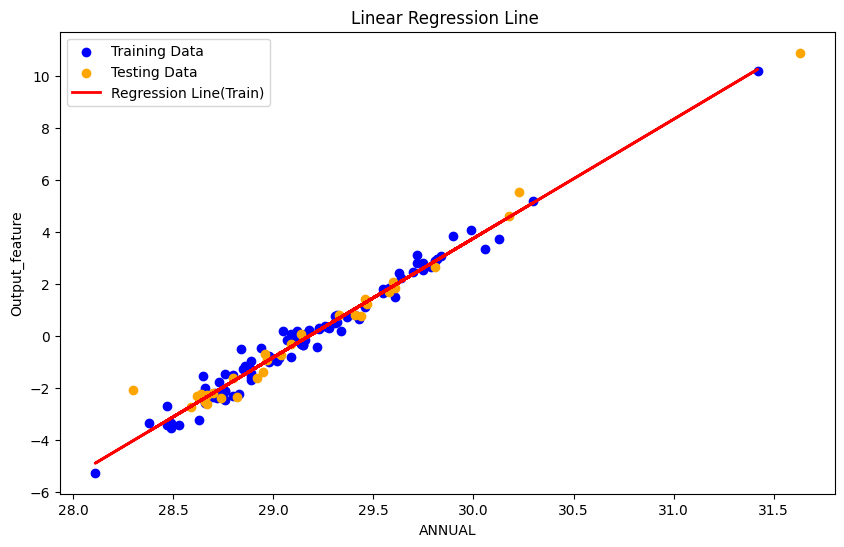

Minimum MSE :0.13


In [32]:
model=LinearRegression()
X_train ,X_test , Y_train , Y_test = train_test_split(X_single,y,test_size=0.25,random_state=42)
model.fit(X_train,Y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)


plt.figure(figsize=(10,6))
plt.scatter(X_train,Y_train,label="Training Data",color="blue")
plt.scatter(X_test,Y_test,label="Testing Data",color="orange")
plt.plot(X_train,y_train_pred,label="Regression Line(Train)",color="red",linewidth=2)
plt.xlabel(input_feature_1)
plt.ylabel("Output_feature")
plt.title("Linear Regression Line ")
plt.legend()
plt.show()



mse_test = mean_squared_error(Y_test,y_test_pred)
mse_train = mean_squared_error(Y_train,y_train_pred)

print(f"Minimum MSE :{mse_train:.2f}")

In [35]:
mse_test = mean_squared_error(Y_test,y_test_pred)
mse_train = mean_squared_error(Y_train,y_train_pred)

print(f"Minimum MSE train :{mse_train:.2f}")
print(f"Minimum MSE test :{mse_test:.2f}")


Minimum MSE train :0.13
Minimum MSE test :0.21


In [37]:
mae_test = mean_absolute_error(Y_test,y_test_pred)
mae_train = mean_absolute_error(Y_train,y_train_pred)

print(f"Minimum MSE train :{mae_train:.2f}")
print(f"Minimum MSE test :{mae_test:.2f}")

Minimum MSE train :0.28
Minimum MSE test :0.29


In [38]:
r2_test = r2_score(Y_test,y_test_pred)
r2_train = r2_score(Y_train,y_train_pred)

print(f"Minimum MSE train :{r2_train:.2f}")
print(f"Minimum MSE test :{r2_test:.2f}")

Minimum MSE train :0.98
Minimum MSE test :0.98
